# **1/ Introduction and set up**

This project explores American Sign Language (ASL) classification using transfer learning and feature extraction. Instead of training a deep CNN from scratch, we use pre-trained models (such as EfficientNet, DenseNet, or ResNet) to extract powerful image features and then feed them into a Random Forest classifier for final prediction.

The dataset consists of images of ASL signs (letters A–E) collected collaboratively by group members. Each member contributed photos of different signs using both their left and right hands. We also got shared images from the other team, making total samples around 600 images. These images were then combined into a unified dataset for training and evaluation, organized into separate folders with 80% training images and 20% validation images, each subfolder representing a class (A–E).

Our data structure is:

    -data
        -train
            -A
                xx.jpg
                xx.jpg
            -B
                xx.jpg
                xx.jpg
            ...
        -val
            -A
                xx.jpg
                xx.jpg
            -B
                xx.jpg
                xx.jpg
            ...

This section sets up the environment by installing required libraries and importing essential modules for image processing, deep learning, machine learning, and data handling.

We also define key hyperparameters such as the device (GPU or CPU), the number of classes, the batch size, the image size, and a random seed to ensure reproducibility.

In [ ]:
!pip install efficientnet_pytorch

In [ ]:
import os
import google.colab as colab
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, models, transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Subset
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, recall_score
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import joblib

In [ ]:
colab.drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ========== CONFIG ==========
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_CLASSES = 5
BATCH_SIZE = 16
IMAGE_SIZE = 256
SEED = 42
train_path = '/content/drive/MyDrive/Datasets/asl_dataset_total/train'
val_path = '/content/drive/MyDrive/Datasets/asl_dataset_total/val'
train_augm_path = '/content/drive/MyDrive/Datasets/asl_dataset_total/train_aug'
val_changed_path = '/content/drive/MyDrive/Datasets/asl_dataset_total/val_changed'
np.random.seed(SEED)
torch.manual_seed(SEED)
print(f"Using device: {DEVICE}")

Using device: cpu


# **2/ Model training stages**

# **Stage 1: Use pre-trained models and Random Forest Classifier on original data set**

👉 In the first stage, we split our original samples into 80% for training and 20% for validation set for each class. We apply standard transformation and normalization on the images to fit the input requirement of the pre-trained models.

In [ ]:
# Transform
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Load data
train_data = ImageFolder(root=train_path, transform=transform)

# Shuffle training data
indices = np.arange(len(train_data))
np.random.shuffle(indices)
shuffled_train_data = Subset(train_data, indices)
val_data = ImageFolder(root=val_path, transform=transform)

train_loader = DataLoader(shuffled_train_data, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False)

#

👉 We utilize and combine multiple pre-trained networks (nameing: ResNet, EfficientNet, DenseNet) to input our image dataset in order to extract relevant features for our classification models.

Each pre-trained model has certain different functionality and is well-known for their application. Therefore, we want to test their application on our data to see which extracted features can boost our classification best.

*  ResNet – a deep residual network that mitigates vanishing gradients through skip connections, enabling effective training of very deep models. Its proven performance on large-scale datasets like ImageNet makes it highly reliable for robust feature extraction.
Model link: https://github.com/KaimingHe/deep-residual-networks

*  EfficientNet – which scales depth, width, and resolution efficiently to achieve high accuracy with fewer parameters, making it computationally efficient for feature extraction.
Model link: https://github.com/tensorflow/tpu/tree/master/models/official/

*  DenseNet – which was included due to its dense connectivity pattern that encourages feature reuse and improves gradient flow, leading to compact and discriminative feature representations.
Model link: https://github.com/liuzhuang13/DenseNet


For the extracted features, we store for each pre-trained networks individually and also stack them together.

In [ ]:
# Load pretrained models
resnet = models.resnet18(pretrained=True)
densenet = models.densenet121(pretrained=True)
efficientnet = models.efficientnet_b0(pretrained=True)

# Modify each model to remove the classification head (so we can use features only)
resnet.fc = nn.Identity()
densenet.classifier = nn.Identity()
efficientnet.classifier = nn.Identity()

# Move models to device
resnet = resnet.to(DEVICE)
densenet = densenet.to(DEVICE)
efficientnet = efficientnet.to(DEVICE)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 361MB/s]
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 220MB/s]
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 318MB/s]


In [ ]:
# Extract features
def extract_features(model, loader):
    model.eval()
    features, labels = [], []
    with torch.no_grad():
        for inputs, targets in tqdm(loader, desc=f"Extracting with {model.__class__.__name__}"):
            inputs = inputs.to(DEVICE)
            outputs = model(inputs)
            features.append(outputs.cpu().numpy())
            labels.extend(targets.numpy())
    return np.vstack(features), np.array(labels)

# Train
resnet_feats_train, y_train = extract_features(resnet, train_loader)
densenet_feats_train, _ = extract_features(densenet, train_loader)
efficientnet_feats_train, _ = extract_features(efficientnet, train_loader)

# Test
resnet_feats_test, y_test = extract_features(resnet, val_loader)
densenet_feats_test, _ = extract_features(densenet, val_loader)
efficientnet_feats_test, _ = extract_features(efficientnet, val_loader)

Extracting with EfficientNet: 100%|██████████| 8/8 [00:02<00:00,  2.78it/s]


👉 Accordingly, in the last phase of our model, we apply RandomForestClassifier on different extracted features bucket, naming:


*   RandomForestClassifier on extracted stacking features of ResNet, EfficientNet, DenseNet
*   RandomForestClassifier on extracted features of ResNet
*   RandomForestClassifier on extracted features of EfficientNet
*   RandomForestClassifier on extracted features of DenseNet
*   Average prediction of RandomForestClassifier on extracted features of ResNet, EfficientNet, DenseNet individually



In [ ]:
# Train stacking random forest model
print("\n📦 Training stacking meta-model (RandomForest on concatenated features)...")
X_train_stack = np.hstack([resnet_feats_train, densenet_feats_train, efficientnet_feats_train])
X_test_stack = np.hstack([resnet_feats_test, densenet_feats_test, efficientnet_feats_test])

stack_model_rf = RandomForestClassifier(n_estimators=200, random_state=SEED).fit(X_train_stack, y_train)
stack_rf_preds = stack_model_rf.predict(X_test_stack)


📦 Training stacking meta-model (RandomForest on concatenated features)...


In [ ]:
# Individual random forest models
print("\n🌲 Training RandomForest classifiers for individual models...")
rf_resnet = RandomForestClassifier(n_estimators=100, random_state=SEED).fit(resnet_feats_train, y_train)
rf_densenet = RandomForestClassifier(n_estimators=100, random_state=SEED).fit(densenet_feats_train, y_train)
rf_efficient = RandomForestClassifier(n_estimators=100, random_state=SEED).fit(efficientnet_feats_train, y_train)

rf_resnet_prob = rf_resnet.predict_proba(resnet_feats_test)
rf_resnet_pred = np.argmax(rf_resnet_prob, axis=1) #prediction using resnet only
rf_densenet_prob = rf_densenet.predict_proba(densenet_feats_test)
rf_densenet_pred = np.argmax(rf_densenet_prob, axis=1) #prediction using densenet only
rf_efficient_prob = rf_efficient.predict_proba(efficientnet_feats_test)
rf_efficient_pred = np.argmax(rf_efficient_prob, axis=1) #prediction using efficient only


🌲 Training RandomForest classifiers for individual models...


In [ ]:
# Random forest average model
print("\n🌲 Training RandomForest classifiers for average of individual models...")

rf_probs = (
    rf_resnet.predict_proba(resnet_feats_test) +
    rf_densenet.predict_proba(densenet_feats_test) +
    rf_efficient.predict_proba(efficientnet_feats_test)
) / 3.0
rf_preds = np.argmax(rf_probs, axis=1)


🌲 Training RandomForest classifiers for average of individual models...


👉 Finally, we evaluate the models accuracy and sensitivity level.

From the below chart result, we see that applying RandomForestClassifier on stacking extracted features give us the best total accuracy and average recall level in predicting A-E classes. The accuracy and recall rate is 99.2%, which is very promising.

In [ ]:
# Evaluation
def evaluate(y_true, y_pred, name):
    print(f"\n🔍 Evaluation: {name}")
    acc = accuracy_score(y_true, y_pred)
    print(f"✅ Accuracy: {acc:.4f}")
    print(classification_report(y_true, y_pred, target_names=train_data.classes))

evaluate(y_test, stack_rf_preds, "Stacking (Concatenated Features → RandomForest)")
evaluate(y_test, rf_resnet_pred, "RestNet - RandomForest")
evaluate(y_test, rf_densenet_pred, "DenseNet - RandomForest")
evaluate(y_test, rf_efficient_pred, "EfficienNet - RandomForest")
evaluate(y_test, rf_preds, "Average probabilities - RandomForest")


🔍 Evaluation: Stacking (Concatenated Features → RandomForest)
✅ Accuracy: 0.9916
              precision    recall  f1-score   support

           A       0.96      1.00      0.98        24
           B       1.00      1.00      1.00        23
           C       1.00      1.00      1.00        24
           D       1.00      1.00      1.00        24
           E       1.00      0.96      0.98        24

    accuracy                           0.99       119
   macro avg       0.99      0.99      0.99       119
weighted avg       0.99      0.99      0.99       119


🔍 Evaluation: RestNet - RandomForest
✅ Accuracy: 0.9748
              precision    recall  f1-score   support

           A       0.92      1.00      0.96        24
           B       1.00      1.00      1.00        23
           C       0.96      1.00      0.98        24
           D       1.00      0.96      0.98        24
           E       1.00      0.92      0.96        24

    accuracy                           0.97   

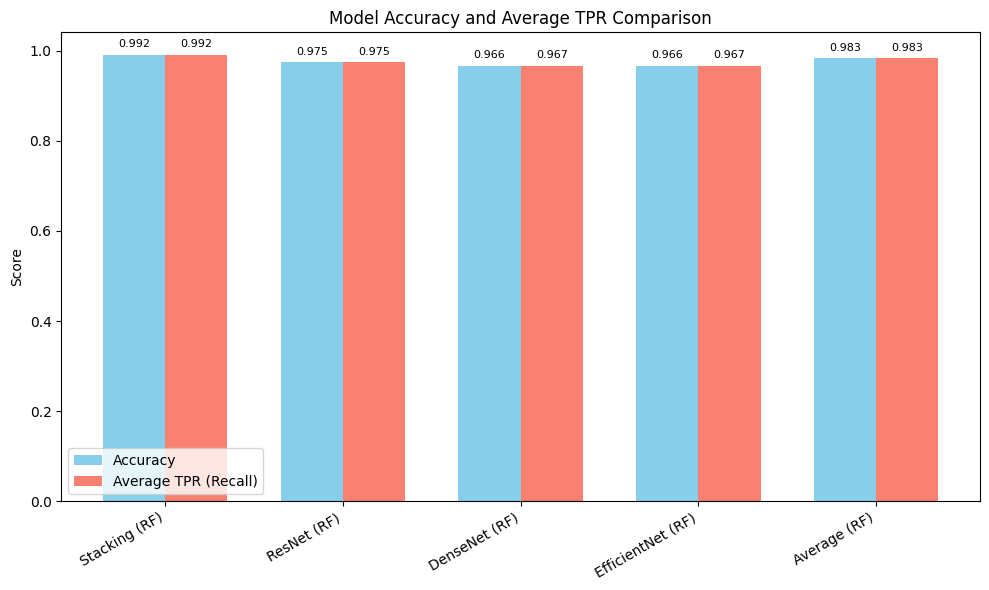

In [ ]:
# Models' predictions dictionary
model_preds = {
    "Stacking (RF)": stack_rf_preds,
    "ResNet (RF)": rf_resnet_pred,
    "DenseNet (RF)": rf_densenet_pred,
    "EfficientNet (RF)": rf_efficient_pred,
    "Average (RF)": rf_preds,
}

accuracies = []
avg_tprs = []

for name, preds in model_preds.items():
    acc = accuracy_score(y_test, preds)
    # Macro average recall = average TPR across classes
    avg_tpr = recall_score(y_test, preds, average='macro')
    accuracies.append(acc)
    avg_tprs.append(avg_tpr)


x = np.arange(len(model_preds))  # positions for bars
width = 0.35  # width of bars

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, accuracies, width, label='Accuracy', color='skyblue')
rects2 = ax.bar(x + width/2, avg_tprs, width, label='Average TPR (Recall)', color='salmon')

# Add text labels above bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f"{height:.3f}",
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 4),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

autolabel(rects1)
autolabel(rects2)

ax.set_ylabel("Score")
ax.set_title("Model Accuracy and Average TPR Comparison")
ax.set_xticks(x)
ax.set_xticklabels(model_preds.keys(), rotation=30, ha='right')
ax.legend()

plt.tight_layout()
plt.show()


# **Stage 2: Use original training model to predict transformed validation set**

👉 Although the models in stage 1 have promissing evaluation result, we want to test the robustness by applying some transformation on to the validation set (resizing, horizontal flip, 45 degree rotation, some jittering), then use the original models to predict such changed validation set.

👉 Clearly we see the accuracy and recal level drops dramatically (only around 80% for stacking model, 83% for average prediction), this demonstrates that the trained models in stage 1 is not robust since it cannot predict the classes effectively when we changes the image a bit.

👉 Besides, the models using extracted features from individual pre-trained models seem more sensitive to changes in validation set as their accuracy dropped faster in this stage.



In [ ]:
def augment_and_save_images(src_folder, dst_folder, num_augments, org_save=True):
    """
    Augments images from a source folder and saves them to a destination folder.

    Args:
        src_folder (str): Path to the source folder containing image subdirectories.
        dst_folder (str): Path to the destination folder to save augmented images.
        num_augments (int): Number of augmented versions to create for each image.
    """
    dataset = ImageFolder(src_folder)
    os.makedirs(dst_folder, exist_ok=True)

    augmen_transforms = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(45),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    ])

    print(f"Augmenting and saving images from {src_folder} to {dst_folder}...")
    for idx, (img, label) in enumerate(tqdm(dataset, desc="Augmenting Images")):
        class_name = dataset.classes[label]
        class_dir = os.path.join(dst_folder, class_name)
        os.makedirs(class_dir, exist_ok=True)

        # Save original image (optional)
        if org_save==True:
          img.save(os.path.join(class_dir, f"{idx}_orig.jpg"))

        for n in range(num_augments):
            aug_img = augmen_transforms(img)
            if not isinstance(aug_img, Image.Image):
                aug_img = transforms.ToPILImage()(aug_img)
            aug_img.save(os.path.join(class_dir, f"{idx}_aug{n}.jpg"))

    print("Augmentation complete.")

In [ ]:
# Only run once to generate data
augment_and_save_images(val_path, val_changed_path, 3, False)

Augmenting and saving images from /content/drive/MyDrive/Datasets/asl_dataset_total/val to /content/drive/MyDrive/Datasets/asl_dataset_total/val_changed...


Augmenting Images: 100%|██████████| 119/119 [00:05<00:00, 22.80it/s]

Augmentation complete.


In [ ]:
# Load data
val_dataset = ImageFolder(root=val_changed_path, transform=transform)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Test
resnet_feats_test, y_test = extract_features(resnet, val_loader)
densenet_feats_test, _ = extract_features(densenet, val_loader)
efficientnet_feats_test, _ = extract_features(efficientnet, val_loader)

# Predict
X_test_stack = np.hstack([resnet_feats_test, densenet_feats_test, efficientnet_feats_test])
stack_rf_preds = stack_model_rf.predict(X_test_stack)

rf_resnet_prob = rf_resnet.predict_proba(resnet_feats_test)
rf_resnet_pred = np.argmax(rf_resnet_prob, axis=1) #prediction using resnet only
rf_densenet_prob = rf_densenet.predict_proba(densenet_feats_test)
rf_densenet_pred = np.argmax(rf_densenet_prob, axis=1) #prediction using densenet only
rf_efficient_prob = rf_efficient.predict_proba(efficientnet_feats_test)
rf_efficient_pred = np.argmax(rf_efficient_prob, axis=1) #prediction using efficient only

rf_probs = (
    rf_resnet.predict_proba(resnet_feats_test) +
    rf_densenet.predict_proba(densenet_feats_test) +
    rf_efficient.predict_proba(efficientnet_feats_test)
) / 3.0
rf_preds = np.argmax(rf_probs, axis=1)

# Evaluation
def evaluate(y_true, y_pred, name):
    print(f"\n🔍 Evaluation: {name}")
    acc = accuracy_score(y_true, y_pred)
    print(f"✅ Accuracy: {acc:.4f}")
    print(classification_report(y_true, y_pred, target_names=train_data.classes))

evaluate(y_test, stack_rf_preds, "Stacking (Concatenated Features → RandomForest)")
evaluate(y_test, rf_resnet_pred, "RestNet - RandomForest")
evaluate(y_test, rf_densenet_pred, "DenseNet - RandomForest")
evaluate(y_test, rf_efficient_pred, "EfficienNet - RandomForest")
evaluate(y_test, rf_preds, "Average probabilities - RandomForest")

Extracting with EfficientNet: 100%|██████████| 23/23 [00:08<00:00,  2.56it/s]



🔍 Evaluation: Stacking (Concatenated Features → RandomForest)
✅ Accuracy: 0.8095
              precision    recall  f1-score   support

           A       0.88      0.69      0.78        72
           B       0.92      0.68      0.78        69
           C       0.67      1.00      0.80        72
           D       0.97      0.83      0.90        72
           E       0.76      0.83      0.79        72

    accuracy                           0.81       357
   macro avg       0.84      0.81      0.81       357
weighted avg       0.84      0.81      0.81       357


🔍 Evaluation: RestNet - RandomForest
✅ Accuracy: 0.7283
              precision    recall  f1-score   support

           A       0.65      0.69      0.67        72
           B       0.94      0.46      0.62        69
           C       0.64      0.97      0.77        72
           D       0.76      0.94      0.84        72
           E       0.85      0.56      0.67        72

    accuracy                           0.73   

# **Stage 3: Apply On-the-fly Augmentation to training data to test robustness**

👉 With the result from stage 2, it is critical to enhance the model robustness so that it can predict transformed data better. Our approach is to apply data augmentation on our training data and train the models again

👉 In this stage, our Agmented training data uses On-the-fly Augmentation. In which, original training images are transformed (augmented) randomly each time they are fetched. It does not physically expand the dataset size on disk. Instead, it transforms the original images differently each time they are loaded, effectively creating new, varied training samples on the fly without increasing storage.

👉 When we use the new trained model to predict the changed validation set (transformations are created on both training and validation set), the model prediction accuracy increases to 90% for stacking model and 95% for average prediction, which is much better than stage 2.


In [ ]:
# Define training transforms with augmentations
train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(45),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# Load datasets
train_dataset = ImageFolder(root=train_path, transform=train_transforms)

# Shuffle training set
indices = np.arange(len(train_dataset))
np.random.shuffle(indices)
shuffled_train_data = Subset(train_dataset, indices)

train_loader = DataLoader(shuffled_train_data, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
# Train
resnet_feats_train, y_train = extract_features(resnet, train_loader)
densenet_feats_train, _ = extract_features(densenet, train_loader)
efficientnet_feats_train, _ = extract_features(efficientnet, train_loader)

# # Test
# resnet_feats_test, y_test = extract_features(resnet, val_loader)
# densenet_feats_test, _ = extract_features(densenet, val_loader)
# efficientnet_feats_test, _ = extract_features(efficientnet, val_loader)

# ========== STACKING MODEL -RandomForest ==========
print("\n📦 Training stacking meta-model (RandomForest on concatenated features)...")
X_train_stack = np.hstack([resnet_feats_train, densenet_feats_train, efficientnet_feats_train])
X_test_stack = np.hstack([resnet_feats_test, densenet_feats_test, efficientnet_feats_test])

stack_model_rf = RandomForestClassifier(n_estimators=200, random_state=SEED)
stack_model_rf.fit(X_train_stack, y_train)
stack_rf_preds = stack_model_rf.predict(X_test_stack)

# ========== RANDOM FOREST INDIVIDUAL MODELS ==========
print("\n🌲 Training RandomForest classifiers for individual models...")
rf_resnet = RandomForestClassifier(n_estimators=100, random_state=SEED).fit(resnet_feats_train, y_train)
rf_densenet = RandomForestClassifier(n_estimators=100, random_state=SEED).fit(densenet_feats_train, y_train)
rf_efficient = RandomForestClassifier(n_estimators=100, random_state=SEED).fit(efficientnet_feats_train, y_train)

rf_resnet_prob = rf_resnet.predict_proba(resnet_feats_test)
rf_resnet_pred = np.argmax(rf_resnet_prob, axis=1) #prediction using resnet only
rf_densenet_prob = rf_densenet.predict_proba(densenet_feats_test)
rf_densenet_pred = np.argmax(rf_densenet_prob, axis=1) #prediction using densenet only
rf_efficient_prob = rf_efficient.predict_proba(efficientnet_feats_test)
rf_efficient_pred = np.argmax(rf_efficient_prob, axis=1) #prediction using efficient only

# ========== RANDOM FOREST AVERAGE MODELS ==========
print("\n🌲 Training RandomForest classifiers for average of individual models...")

rf_probs = (
    rf_resnet.predict_proba(resnet_feats_test) +
    rf_densenet.predict_proba(densenet_feats_test) +
    rf_efficient.predict_proba(efficientnet_feats_test)
) / 3.0
rf_preds = np.argmax(rf_probs, axis=1)


# ========== EVALUATION FUNCTION ==========
def evaluate(y_true, y_pred, name):
    print(f"\n🔍 Evaluation: {name}")
    acc = accuracy_score(y_true, y_pred)
    print(f"✅ Accuracy: {acc:.4f}")
    print(classification_report(y_true, y_pred, target_names=train_data.classes))

evaluate(y_test, stack_rf_preds, "Stacking (Concatenated Features → RandomForest)")
evaluate(y_test, rf_resnet_pred, "RestNet - RandomForest")
evaluate(y_test, rf_densenet_pred, "DenseNet - RandomForest")
evaluate(y_test, rf_efficient_pred, "EfficienNet - RandomForest")
evaluate(y_test, rf_preds, "Average probabilities - RandomForest")

Extracting with EfficientNet: 100%|██████████| 31/31 [00:12<00:00,  2.46it/s]



📦 Training stacking meta-model (RandomForest on concatenated features)...

🌲 Training RandomForest classifiers for individual models...

🌲 Training RandomForest classifiers for average of individual models...

🔍 Evaluation: Stacking (Concatenated Features → RandomForest)
✅ Accuracy: 0.9076
              precision    recall  f1-score   support

           A       0.96      0.76      0.85        72
           B       0.92      1.00      0.96        69
           C       0.86      0.99      0.92        72
           D       1.00      0.83      0.91        72
           E       0.84      0.96      0.90        72

    accuracy                           0.91       357
   macro avg       0.92      0.91      0.91       357
weighted avg       0.92      0.91      0.91       357


🔍 Evaluation: RestNet - RandomForest
✅ Accuracy: 0.8459
              precision    recall  f1-score   support

           A       0.72      0.78      0.75        72
           B       0.84      0.93      0.88        69

#

👉 We also apply the new model using Agmented training data (On-the-fly Augmentation) to predict the original validation set, the model accuracy remains quite high but a little decrease for DenseNet, EffectiveNet and Average model.

👉 This is the trade-off of using On-the-fly Augmentation, it can save memory but by not keeping the original data set, so it can to predict original image at certain level.


In [ ]:
# ========== LOAD DATA ==========
val_data = datasets.ImageFolder(root=val_path, transform=transform)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False)

# Test
resnet_feats_test, y_test = extract_features(resnet, val_loader)
densenet_feats_test, _ = extract_features(densenet, val_loader)
efficientnet_feats_test, _ = extract_features(efficientnet, val_loader)

# Predict
X_test_stack = np.hstack([resnet_feats_test, densenet_feats_test, efficientnet_feats_test])
stack_rf_preds = stack_model_rf.predict(X_test_stack)

rf_resnet_prob = rf_resnet.predict_proba(resnet_feats_test)
rf_resnet_pred = np.argmax(rf_resnet_prob, axis=1) #prediction using resnet only
rf_densenet_prob = rf_densenet.predict_proba(densenet_feats_test)
rf_densenet_pred = np.argmax(rf_densenet_prob, axis=1) #prediction using densenet only
rf_efficient_prob = rf_efficient.predict_proba(efficientnet_feats_test)
rf_efficient_pred = np.argmax(rf_efficient_prob, axis=1) #prediction using efficient only

rf_probs = (
    rf_resnet.predict_proba(resnet_feats_test) +
    rf_densenet.predict_proba(densenet_feats_test) +
    rf_efficient.predict_proba(efficientnet_feats_test)
) / 3.0
rf_preds = np.argmax(rf_probs, axis=1)

# ========== EVALUATION FUNCTION ==========
def evaluate(y_true, y_pred, name):
    print(f"\n🔍 Evaluation: {name}")
    acc = accuracy_score(y_true, y_pred)
    print(f"✅ Accuracy: {acc:.4f}")
    print(classification_report(y_true, y_pred, target_names=train_data.classes))

evaluate(y_test, stack_rf_preds, "Stacking (Concatenated Features → RandomForest)")
evaluate(y_test, rf_resnet_pred, "RestNet - RandomForest")
evaluate(y_test, rf_densenet_pred, "DenseNet - RandomForest")
evaluate(y_test, rf_efficient_pred, "EfficienNet - RandomForest")
evaluate(y_test, rf_preds, "Average probabilities - RandomForest")

Extracting with EfficientNet: 100%|██████████| 8/8 [00:03<00:00,  2.55it/s]



🔍 Evaluation: Stacking (Concatenated Features → RandomForest)
✅ Accuracy: 0.9160
              precision    recall  f1-score   support

           A       1.00      0.75      0.86        24
           B       0.92      1.00      0.96        23
           C       1.00      0.92      0.96        24
           D       1.00      0.92      0.96        24
           E       0.75      1.00      0.86        24

    accuracy                           0.92       119
   macro avg       0.93      0.92      0.92       119
weighted avg       0.93      0.92      0.92       119


🔍 Evaluation: RestNet - RandomForest
✅ Accuracy: 0.8571
              precision    recall  f1-score   support

           A       0.85      0.71      0.77        24
           B       0.81      0.91      0.86        23
           C       0.88      0.92      0.90        24
           D       0.95      0.88      0.91        24
           E       0.81      0.88      0.84        24

    accuracy                           0.86   

# **Stage 4: Apply augmentation with expanding dataset to enhance robustness**

👉 In this stage, we use Augmented training set (Offline augmentation), this approach will keep our original training data set and expand it with the new transformed images. This will surely make our training set more profound and escape the trade off of On-the-fly Augmentation in Stage 3.

👉 We then apply the new models of Augmented training set using Offline augmentation to predict the original validation set. The accuracy is very powerfull of 100% for stacking model and average prediction.

**You can skip model training by load three models files in modesl folder**

In [ ]:
# Only run once to generate data
augment_and_save_images(train_path, train_augm_path, 3)

Augmenting and saving images from /content/drive/MyDrive/EnsembleModel/dataset_final/train to /content/drive/MyDrive/EnsembleModel/dataset_final/train_aug...


Augmenting Images: 100%|██████████| 489/489 [00:32<00:00, 15.24it/s]

Augmentation complete.


In [ ]:
# Load datasets
train_dataset = ImageFolder(root=train_augm_path, transform=transform)

indices = np.arange(len(train_dataset))
np.random.shuffle(indices)
shuffled_train_data = Subset(train_dataset, indices)

train_loader = DataLoader(shuffled_train_data, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
val_dataset = ImageFolder(root=val_path, transform=transform)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
# Train feature extraction
resnet_feats_train, y_train = extract_features(resnet, train_loader)
densenet_feats_train, _ = extract_features(densenet, train_loader)
efficientnet_feats_train, _ = extract_features(efficientnet, train_loader)

X_train_stack = np.hstack([resnet_feats_train, densenet_feats_train, efficientnet_feats_train])

Extracting with EfficientNet: 100%|██████████| 123/123 [00:51<00:00,  2.38it/s]


In [ ]:
# Test feature extraction
resnet_feats_test, y_test = extract_features(resnet, val_loader)
densenet_feats_test, _ = extract_features(densenet, val_loader)
efficientnet_feats_test, _ = extract_features(efficientnet, val_loader)

X_test_stack = np.hstack([resnet_feats_test, densenet_feats_test, efficientnet_feats_test])

Extracting with EfficientNet: 100%|██████████| 8/8 [00:03<00:00,  2.66it/s]


In [ ]:
# Train models
stack_model_rf = RandomForestClassifier(n_estimators=200, random_state=SEED)
stack_model_rf.fit(X_train_stack, y_train)

# ========== RANDOM FOREST INDIVIDUAL MODELS ==========
print("\n🌲 Training RandomForest classifiers for individual models...")
rf_resnet = RandomForestClassifier(n_estimators=100, random_state=SEED).fit(resnet_feats_train, y_train)
rf_densenet = RandomForestClassifier(n_estimators=100, random_state=SEED).fit(densenet_feats_train, y_train)
rf_efficient = RandomForestClassifier(n_estimators=100, random_state=SEED).fit(efficientnet_feats_train, y_train)


🌲 Training RandomForest classifiers for individual models...


In [ ]:
# Save the model
joblib.dump(stack_model_rf, 'models/stack_model_rf.joblib')
joblib.dump(rf_resnet, 'models/rf_resnet.joblib')
joblib.dump(rf_densenet, 'models/rf_densenet.joblib')
joblib.dump(rf_efficient, 'models/rf_efficient.joblib')

['models/rf_efficient.joblib']

In [ ]:
# Load the model. If load the model file, don't need to train again.
stack_model_rf = joblib.load('models/stack_model_rf.joblib')
rf_resnet = joblib.load('models/rf_resnet.joblib')
rf_densenet = joblib.load('models/rf_densenet.joblib')
rf_efficient = joblib.load('models/rf_efficient.joblib')

In [ ]:
# Prediction
stack_rf_preds = stack_model_rf.predict(X_test_stack)

rf_resnet_prob = rf_resnet.predict_proba(resnet_feats_test)
rf_resnet_pred = np.argmax(rf_resnet_prob, axis=1) #prediction using resnet only
rf_densenet_prob = rf_densenet.predict_proba(densenet_feats_test)
rf_densenet_pred = np.argmax(rf_densenet_prob, axis=1) #prediction using densenet only
rf_efficient_prob = rf_efficient.predict_proba(efficientnet_feats_test)
rf_efficient_pred = np.argmax(rf_efficient_prob, axis=1) #prediction using efficient only

rf_probs = (
    rf_resnet.predict_proba(resnet_feats_test) +
    rf_densenet.predict_proba(densenet_feats_test) +
    rf_efficient.predict_proba(efficientnet_feats_test)
) / 3.0
rf_preds = np.argmax(rf_probs, axis=1)

In [ ]:
# ========== EVALUATION FUNCTION ==========
def evaluate(y_true, y_pred, name):
    print(f"\n🔍 Evaluation: {name}")
    acc = accuracy_score(y_true, y_pred)
    print(f"✅ Accuracy: {acc:.4f}")
    print(classification_report(y_true, y_pred, target_names=train_dataset.classes))

evaluate(y_test, stack_rf_preds, "Stacking (Concatenated Features → RandomForest)")
evaluate(y_test, rf_resnet_pred, "RestNet - RandomForest")
evaluate(y_test, rf_densenet_pred, "DenseNet - RandomForest")
evaluate(y_test, rf_efficient_pred, "EfficienNet - RandomForest")
evaluate(y_test, rf_preds, "Average probabilities - RandomForest")


🔍 Evaluation: Stacking (Concatenated Features → RandomForest)
✅ Accuracy: 1.0000
              precision    recall  f1-score   support

           A       1.00      1.00      1.00        24
           B       1.00      1.00      1.00        23
           C       1.00      1.00      1.00        24
           D       1.00      1.00      1.00        24
           E       1.00      1.00      1.00        24

    accuracy                           1.00       119
   macro avg       1.00      1.00      1.00       119
weighted avg       1.00      1.00      1.00       119


🔍 Evaluation: RestNet - RandomForest
✅ Accuracy: 0.9748
              precision    recall  f1-score   support

           A       0.89      1.00      0.94        24
           B       1.00      1.00      1.00        23
           C       1.00      1.00      1.00        24
           D       1.00      1.00      1.00        24
           E       1.00      0.88      0.93        24

    accuracy                           0.97   

#

👉 Finally, we also use the same final models to predict the transformed validation set. The accuracy level reaches 99%.

In [ ]:
# ========== LOAD DATA ==========
val_dataset = ImageFolder(root=val_changed_path, transform=transform)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
# Test
resnet_feats_test, y_test = extract_features(resnet, val_loader)
densenet_feats_test, _ = extract_features(densenet, val_loader)
efficientnet_feats_test, _ = extract_features(efficientnet, val_loader)

# ========== STACKING MODEL -RandomForest ==========
print("\n📦 Training stacking meta-model (RandomForest on concatenated features)...")
X_test_stack = np.hstack([resnet_feats_test, densenet_feats_test, efficientnet_feats_test])

Extracting with EfficientNet: 100%|██████████| 23/23 [00:09<00:00,  2.42it/s]


📦 Training stacking meta-model (RandomForest on concatenated features)...


In [ ]:
# Prediction
stack_rf_preds = stack_model_rf.predict(X_test_stack)

rf_resnet_prob = rf_resnet.predict_proba(resnet_feats_test)
rf_resnet_pred = np.argmax(rf_resnet_prob, axis=1) #prediction using resnet only
rf_densenet_prob = rf_densenet.predict_proba(densenet_feats_test)
rf_densenet_pred = np.argmax(rf_densenet_prob, axis=1) #prediction using densenet only
rf_efficient_prob = rf_efficient.predict_proba(efficientnet_feats_test)
rf_efficient_pred = np.argmax(rf_efficient_prob, axis=1) #prediction using efficient only

rf_probs = (
    rf_resnet.predict_proba(resnet_feats_test) +
    rf_densenet.predict_proba(densenet_feats_test) +
    rf_efficient.predict_proba(efficientnet_feats_test)
) / 3.0
rf_preds = np.argmax(rf_probs, axis=1)

In [ ]:
# ========== EVALUATION FUNCTION ==========
def evaluate(y_true, y_pred, name):
    print(f"\n🔍 Evaluation: {name}")
    acc = accuracy_score(y_true, y_pred)
    print(f"✅ Accuracy: {acc:.4f}")
    print(classification_report(y_true, y_pred, target_names=train_dataset.classes))

evaluate(y_test, stack_rf_preds, "Stacking (Concatenated Features → RandomForest)")
evaluate(y_test, rf_resnet_pred, "RestNet - RandomForest")
evaluate(y_test, rf_densenet_pred, "DenseNet - RandomForest")
evaluate(y_test, rf_efficient_pred, "EfficienNet - RandomForest")
evaluate(y_test, rf_preds, "Average probabilities - RandomForest")


🔍 Evaluation: Stacking (Concatenated Features → RandomForest)
✅ Accuracy: 0.9860
              precision    recall  f1-score   support

           A       0.99      0.96      0.97        72
           B       0.96      1.00      0.98        69
           C       1.00      1.00      1.00        72
           D       1.00      0.99      0.99        72
           E       0.99      0.99      0.99        72

    accuracy                           0.99       357
   macro avg       0.99      0.99      0.99       357
weighted avg       0.99      0.99      0.99       357


🔍 Evaluation: RestNet - RandomForest
✅ Accuracy: 0.9328
              precision    recall  f1-score   support

           A       0.83      0.93      0.88        72
           B       0.94      0.97      0.96        69
           C       0.96      0.96      0.96        72
           D       1.00      0.97      0.99        72
           E       0.95      0.83      0.89        72

    accuracy                           0.93   

# ✅ Summary:

The models of Augmented training set using Offline augmentation give the sweatest spot in balancing the prediction of both original and transformed images.

We increase our model accuracy and robustness through each training stage to ensure that the model can predict the class correctly when we make certain challenges (transformation) to the input images.


Accuracy summary of RandomForestClassifier of different pre-train model bucket through each training stage:



| Training Stage | Training Data           | Validation Data        | Stacking | ResNet  | DenseNet | EfficientNet | Average |
|----------------|-------------------------|-------------------------|-----------|----------|-----------|---------------|----------|
| Stage 1        | Original                | Original                | 99.20%    | 97.50%   | 96.60%    | 96.60%        | 98.30%   |
| Stage 2        | Original                | Transformed             | 80.95%    | 72.80%   | 71.99%    | 75.35%        | 83.50%   |
| Stage 3        | On-the-fly transformed  | Transformed             | 90.76%    | 84.60%   | 77.03%    | 85.71%        | 94.96%   |
| Stage 3        | On-the-fly transformed  | Original                | 91.60%    | 85.71%   | 65.55%    | 88.24%        | 94.12%   |
| Stage 4        | Transformed & expanded  | Original                | 100.00%   | 97.48%   | 97.48%    | 99.16%        | 100.00%  |
| Stage 4        | Transformed & expanded  | Transformed             | 98.60%    | 93.28%   | 94.96%    | 96.36%        | 98.88%   |



# **3/ Team member contribution**



*   **Data collection**: All members collected the pictures according to guidelines then we combine together for the mutual dataset
*   **Testing models**: ALL members discussed the potential model approaches, designed the methodology and model combination. Then all of us built our own notebooks to test the discussed models and compared the result.
*   **Finalizing training stages**: ALL members discussed again on the individual notebooks and the results to decided the final training stages we will build for our final team notebook. The best model results from all team members are shared in a same notebook.

*   **Fixing final notebook's codeblock**: Eric and Viet fixed the coding issues identified in our meeting and combined the coding stages together.
*   **Analysis methodology description**: Kim and Zhu inputed all the text blocks in final notebook to describe the the detailed methodology and results.



